In [1]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
import matplotlib.pyplot as plt
import numpy as np
import os

Found 5216 images belonging to 2 classes.
Found 16 images belonging to 2 classes.
Found 624 images belonging to 2 classes.


C:\Users\bharg\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
C:\Users\bharg\anaconda3\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 298s 2s/step - accuracy: 0.7417 - loss: 0.6295 - val_accuracy: 0.6250 - val_loss: 1.2295
Epoch 2/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 288s 2s/step - accuracy: 0.8638 - loss: 0.3207 - val_accuracy: 0.8125 - val_loss: 0.4824
Epoch 3/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 283s 2s/step - accuracy: 0.9032 - loss: 0.2385 - val_accuracy: 0.6875 - val_loss: 0.6624
Epoch 4/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 323s 2s/step - accuracy: 0.9113 - loss: 0.2226 - val_accuracy: 0.8125 - val_loss: 0.3871
Epoch 5/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 314s 2s/step - accuracy: 0.9032 - loss: 0.2407 - val_accuracy: 0.8125 - val_loss: 0.5477
Epoch 6/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 289s 2s/step - accuracy: 0.9179 - loss: 0.2231 - val_accuracy: 0.8125 - val_loss: 0.6115
Epoch 7/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 302s 2s/step - accuracy: 0.9288 - loss: 0.1864 - val_accuracy: 0.8125 - val_loss: 0.4156
Epoch 8/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 287s 2s/step - accuracy: 0.9299 - loss: 0.1811 - val_accu

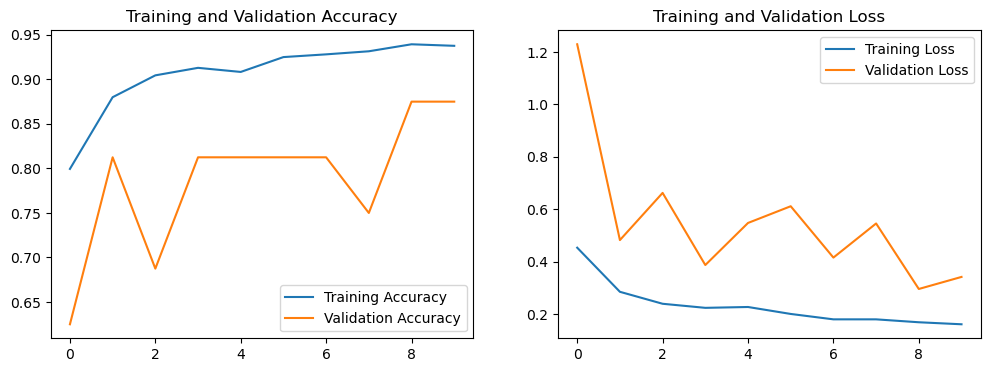

In [3]:
# Define data directories
train_dir = 'C:/pneumonia project/chest_xray/train'
val_dir = 'C:/pneumonia project/chest_xray/val'
test_dir = 'C:/pneumonia project/chest_xray/test'

# Image dimensions and batch size
img_width, img_height = 150, 150
batch_size = 32

# Data augmentation for training data
train_datagen = ImageDataGenerator(
    rescale=1./255,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True
)

# Rescaling for validation and test data
val_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

# Load training, validation, and test data
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(img_width, img_height),
    batch_size=batch_size,
    class_mode='binary'
)

val_generator = val_datagen.flow_from_directory(
    val_dir,
    target_size=(img_width, img_height),
    batch_size=batch_size,
    class_mode='binary'
)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(img_width, img_height),
    batch_size=batch_size,
    class_mode='binary'
)

# Build the CNN model
model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(img_width, img_height, 3)),
    MaxPooling2D((2, 2)),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

# Compile the model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Train the model
history = model.fit(
    train_generator,
    epochs=10,
    validation_data=val_generator
)

# Evaluate the model on the test set
test_loss, test_accuracy = model.evaluate(test_generator)
print(f'Test Accuracy: {test_accuracy}')

# Save the model
model.save('CNN_model.keras')
# Plot training and validation accuracy and loss
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title('Training and Validation Loss')
plt.show()


In [5]:
# Display sample images and their predictions
import random
import cv2

def display_random_images(directory, num_images=5):
    class_names = ['NORMAL', 'PNEUMONIA']
    all_images = []
    all_labels = []

    for class_name in class_names:
        class_dir = os.path.join(directory, class_name)
        image_files = [os.path.join(class_dir, f) for f in os.listdir(class_dir) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
        all_images.extend(image_files)
        all_labels.extend([class_names.index(class_name)] * len(image_files))

    random_indices = random.sample(range(len(all_images)), num_images)
    plt.figure(figsize=(15, 5))

    for i, index in enumerate(random_indices):
        img_path = all_images[index]
        label = all_labels[index]
        img = cv2.imread(img_path)
        img = cv2.resize(img, (img_width, img_height))
        img = img / 255.0  # Rescale for prediction

        img_array = np.expand_dims(img, axis=0)
        prediction = model.predict(img_array)
        predicted_class = 1 if prediction[0][0] > 0.5 else 0

        plt.subplot(1, num_images, i + 1)
        plt.imshow(img)
        plt.title(f'Actual: {class_names[label]}\nPredicted: {class_names[predicted_class]}')
        plt.axis('off')

    plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 257ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step


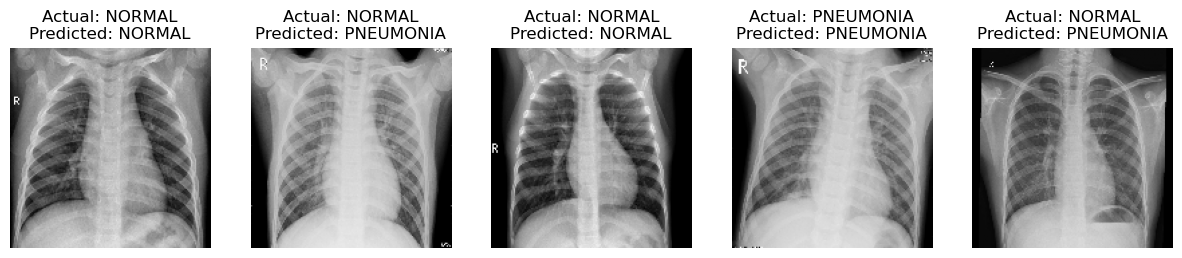

163/163 ━━━━━━━━━━━━━━━━━━━━ 78s 480ms/step - accuracy: 0.9549 - loss: 0.1162
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 196ms/step - accuracy: 0.8750 - loss: 0.3418
Train Accuracy: 0.9543711543083191
Validation Accuracy: 0.875
Test Accuracy: 0.8862179517745972


In [7]:
# Display random images from the test set
display_random_images(test_dir)

#get the accuracy from each set.
train_loss, train_acc = model.evaluate(train_generator)
val_loss, val_acc = model.evaluate(val_generator)

print(f"Train Accuracy: {train_acc}")
print(f"Validation Accuracy: {val_acc}")
print(f"Test Accuracy: {test_accuracy}") #already defined above.

20/20 ━━━━━━━━━━━━━━━━━━━━ 5s 266ms/step


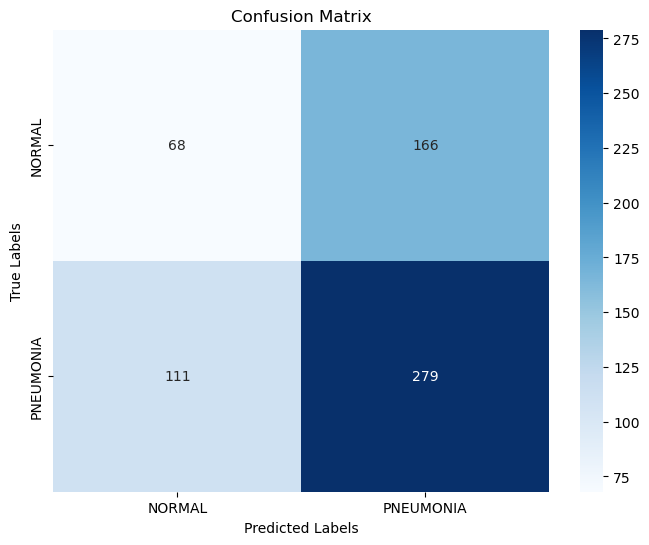

In [17]:
# Predict on the test set
from sklearn.metrics import confusion_matrix
import seaborn as sns
predictions = model.predict(test_generator)
y_pred = (predictions > 0.5).astype(int)
y_true = test_generator.classes

# Calculate the confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Plot the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['NORMAL', 'PNEUMONIA'], yticklabels=['NORMAL', 'PNEUMONIA'])
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()